In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from vis_functions import plot_effect_heatmap, aggregate_any_effect, plot_effect_heatmap_hierarchical, process_df
from def_proj_functions import languages, models, definition_models, lang_specific_models, lang_specific_model_names

df = pd.read_csv('/Users/acw747/Projects/definition_projection/results/master_results_spaces.csv')
print(len(df))

# keep only used spaces
spaces = ['full','def','pca','rand'] 
df = df[df['space'].isin(spaces)]  

# keep only used metrics
metrics = ['apd','prt','amd','amd_sym']
df = df[df['metric'].isin(metrics)]

# rename amd_sym to samd
df['metric'] = df['metric'].replace({'amd_sym':'samd'})
metrics = ['apd','prt','amd','samd']

df = process_df(df)

# keep the last occurrence of each duplicate - in case I re-ran some experiments
df = df.drop_duplicates(subset=['language','encoder','definition_gen_model','metric','space','metric_space'], keep='last')

print(df['space'].unique().tolist())
print(df['metric'].unique().tolist())
print(df['metric_space'].unique().tolist())
print(len(df))

7280
['full', 'pca', 'def', 'rand']
['prt', 'apd', 'amd', 'samd']
['prt_full', 'apd_full', 'amd_full', 'samd_full', 'prt_pca', 'apd_pca', 'amd_pca', 'samd_pca', 'prt_def', 'apd_def', 'amd_def', 'samd_def', 'prt_rand', 'apd_rand', 'amd_rand', 'samd_rand']
768


[Count summary] mean=48.00, min=48, max=48


/Users/acw747/Projects/definition_projection/vis_functions.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([factor1, factor2])["spearman"]
/Users/acw747/Projects/definition_projection/vis_functions.py:433: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = effect_df.groupby([row_col, col_col])["count"].mean()
/Users/acw747/Projects/definition_projection/vis_functions.py:66: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mean_mat = 

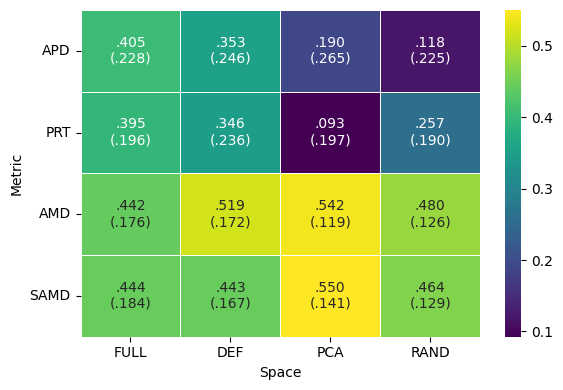

/Users/acw747/Projects/definition_projection/vis_functions.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([factor1, factor2])["spearman"]
/Users/acw747/Projects/definition_projection/vis_functions.py:433: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = effect_df.groupby([row_col, col_col])["count"].mean()
/Users/acw747/Projects/definition_projection/vis_functions.py:212: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mean_mat =

[Count summary] mean=1.00, min=1, max=1


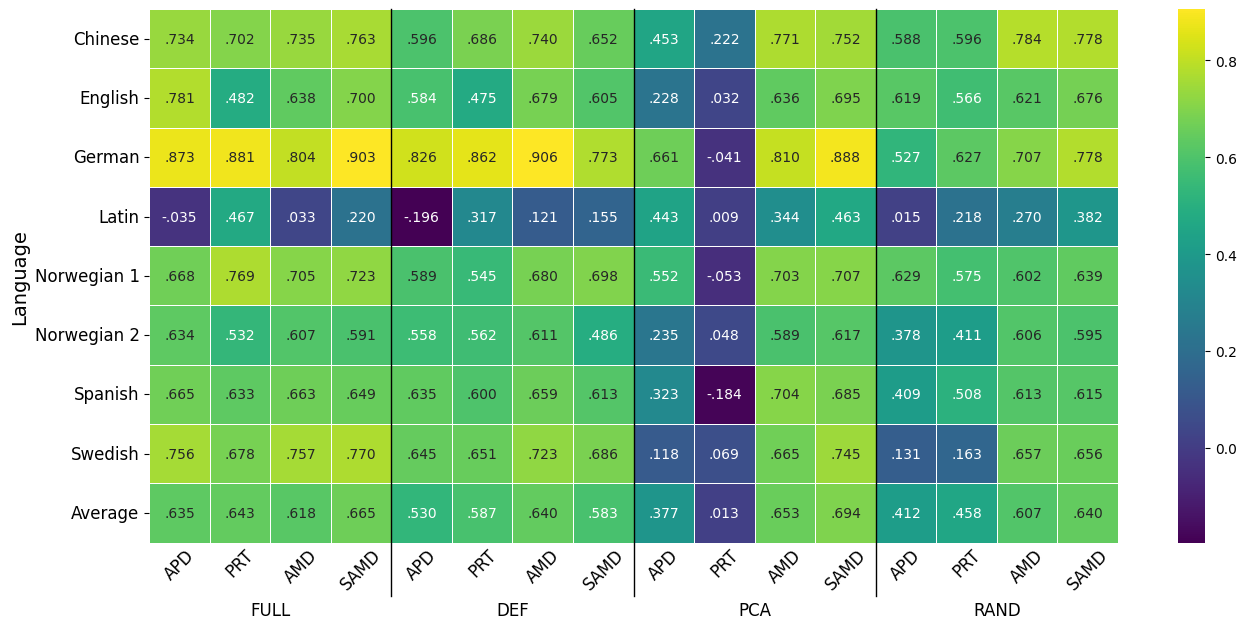

[Count summary] mean=1.00, min=1, max=1


/Users/acw747/Projects/definition_projection/vis_functions.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([factor1, factor2])["spearman"]
/Users/acw747/Projects/definition_projection/vis_functions.py:433: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = effect_df.groupby([row_col, col_col])["count"].mean()
/Users/acw747/Projects/definition_projection/vis_functions.py:212: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mean_mat =

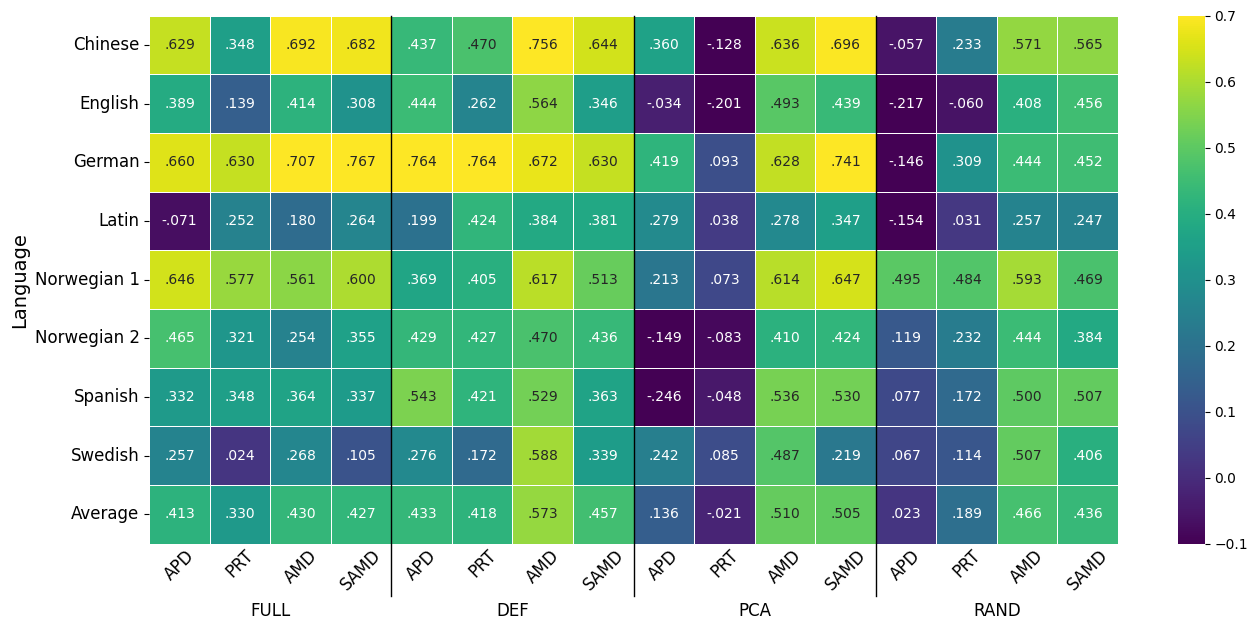

/Users/acw747/Projects/definition_projection/vis_functions.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([factor1, factor2])["spearman"]
/Users/acw747/Projects/definition_projection/vis_functions.py:433: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = effect_df.groupby([row_col, col_col])["count"].mean()
/Users/acw747/Projects/definition_projection/vis_functions.py:212: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mean_mat =

[Count summary] mean=4.00, min=4, max=4


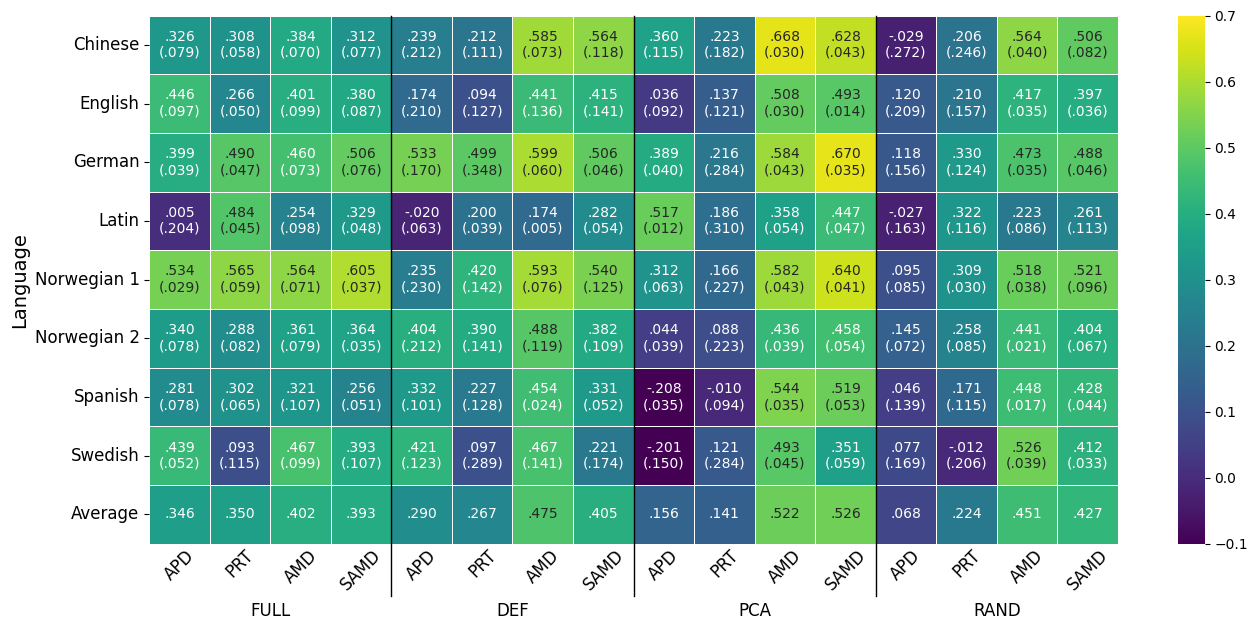

In [ ]:
# Figure 1 - overall effect of different dimension reduction methods across all encoders and languages
encoder_def_effect = aggregate_any_effect(df, "metric", "space")
mean_df, std_df = plot_effect_heatmap(encoder_def_effect, row_col="metric", col_col="space", title="", sort_cols=True, print_table=False, spaces=spaces, metrics=metrics, sort_rows=True)

# Figure 2 - XL-Lexeme only results
df_xll = df[df['encoder'] == 'xll']
# encoder_def_effect = aggregate_any_effect(df_xll, "metric", "space")
# mean_df, std_df = plot_effect_heatmap(encoder_def_effect, row_col="metric", col_col="space", title="", sort_cols=True, print_table=False, spaces=spaces) 
encoder_def_effect = aggregate_any_effect(df_xll, "language", "metric_space")
mean_df, std_df = plot_effect_heatmap_hierarchical(encoder_def_effect, row_col="language", col_col="metric_space", title="", sort_cols=True, print_table=False, spaces=spaces, metrics=metrics)

# Figure 3A - Monolingual model only results
df_mono = df[df['encoder'] == 'monolingual_model']
# encoder_def_effect = aggregate_any_effect(df_mono, "metric", "space")
# mean_df, std_df = plot_effect_heatmap(encoder_def_effect, row_col="metric", col_col="space", title="", sort_cols=True, print_table=False, spaces=spaces, metrics=metrics)
encoder_def_effect = aggregate_any_effect(df_mono, "language", "metric_space")
mean_df, std_df = plot_effect_heatmap_hierarchical(encoder_def_effect, row_col="language", col_col="metric_space", title="", sort_cols=True, print_table=False, spaces=spaces, metrics = metrics,vmin=-0.1, vmax=0.7) 

# Figure 3B - Multilingual models only results
df_multi = df[df['encoder'] != 'xll']
df_multi = df_multi[df_multi['encoder'] != 'monolingual_model']
# encoder_def_effect = aggregate_any_effect(df_multi, "metric", "space")
# mean_df, std_df = plot_effect_heatmap(encoder_def_effect, row_col="metric", col_col="space", title="", sort_cols=True, print_table=False, spaces=spaces) 
encoder_def_effect = aggregate_any_effect(df_multi, "language", "metric_space")
mean_df, std_df = plot_effect_heatmap_hierarchical(encoder_def_effect, row_col="language", col_col="metric_space", title="", sort_cols=True, print_table=False, spaces=spaces, metrics=metrics, vmin=-0.1, vmax=0.7) 


/Users/acw747/Projects/definition_projection/vis_functions.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([factor1, factor2])["spearman"]
/Users/acw747/Projects/definition_projection/vis_functions.py:433: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = effect_df.groupby([row_col, col_col])["count"].mean()
/Users/acw747/Projects/definition_projection/vis_functions.py:212: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mean_mat =

[Count summary] mean=5.99, min=3, max=6


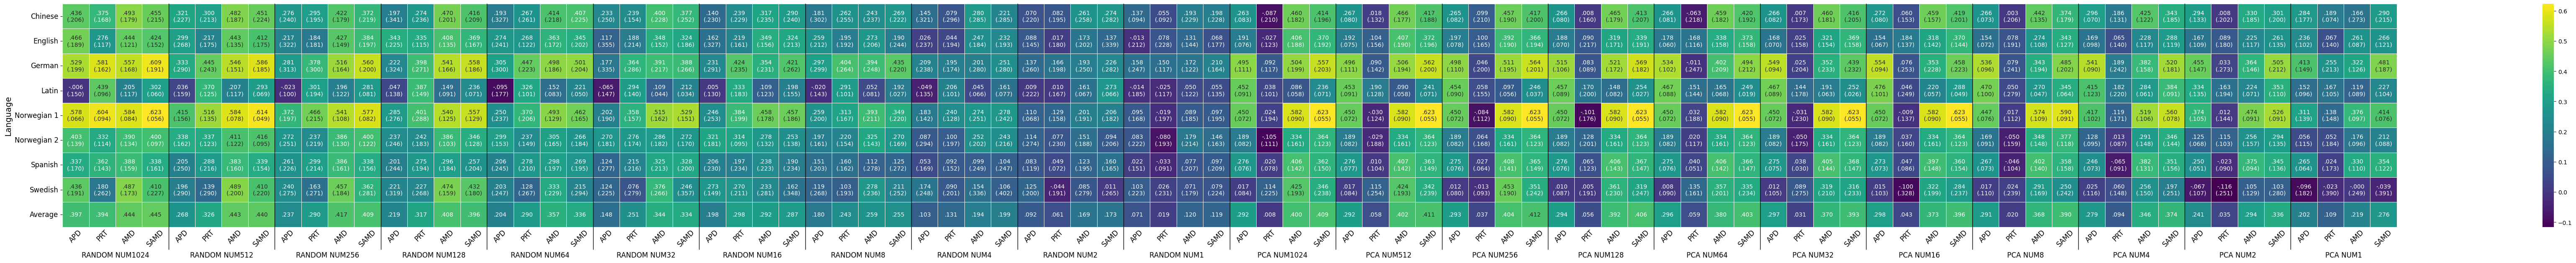

In [ ]:
# Load the right df data for plotting the stress test
df = pd.read_csv('./results/master_results_spaces.csv')

# rename amd_sym to samd
df['metric'] = df['metric'].replace({'amd_sym':'samd'})




num_dimensions = [1024, 512, 256, 128, 64, 32, 16, 8, 4, 2, 1]
spaces = [f'random_num{num_dim}' for num_dim in num_dimensions] + [f'pca_num{num_dim}' for num_dim in num_dimensions]
df = df[df['space'].isin(spaces)]  

# keep only used metrics
metrics = ['apd','prt','amd','samd'] #,'amd_sym','amd_opt_sym']
df = df[df['metric'].isin(metrics)]

# rename 'dim_rm' space ro 'rand'
spaces = [s.replace('dim_rm', 'rand') for s in spaces]

# create metric_space column with process_df
df = process_df(df)

# keep the last occurrence of each duplicate - in case I re-ran some experiments
df = df.drop_duplicates(subset=['language','encoder','definition_gen_model','metric','space','metric_space'], keep='last')

# keep only XL-Lexeme results
# df = df[df['encoder'] == 'xll']


encoder_def_effect = aggregate_any_effect(df, "language", "metric_space")
mean_df, std_df = plot_effect_heatmap_hierarchical(encoder_def_effect, row_col="language", col_col="metric_space", title="", sort_cols=True, print_table=False, spaces=spaces) 


[np.float64(0.29710416666666667), np.float64(0.2979375), np.float64(0.2906458333333333), np.float64(0.27941666666666665), np.float64(0.241375), np.float64(0.20245833333333335)] [np.float64(0.08373513387745042), np.float64(0.08388598623656107), np.float64(0.08631741150713997), np.float64(0.0959214394089383), np.float64(0.10695000742067384), np.float64(0.128218574024166)]
Plotting metric apd in space pca: y=[0.29710417 0.2979375  0.29064583 0.27941667 0.241375   0.20245833], e=[0.08373513 0.08388599 0.08631741 0.09592144 0.10695001 0.12821857]
[np.float64(0.03089583333333333), np.float64(0.04270833333333333), np.float64(0.019520833333333334), np.float64(0.09364583333333333), np.float64(0.03520833333333334), np.float64(0.10858333333333334)] [np.float64(0.17807794516176598), np.float64(0.18788041836674424), np.float64(0.1914190711667273), np.float64(0.15387706987092625), np.float64(0.17952894368055738), np.float64(0.17847818833273132)]
Plotting metric prt in space pca: y=[0.03089583 0.0427

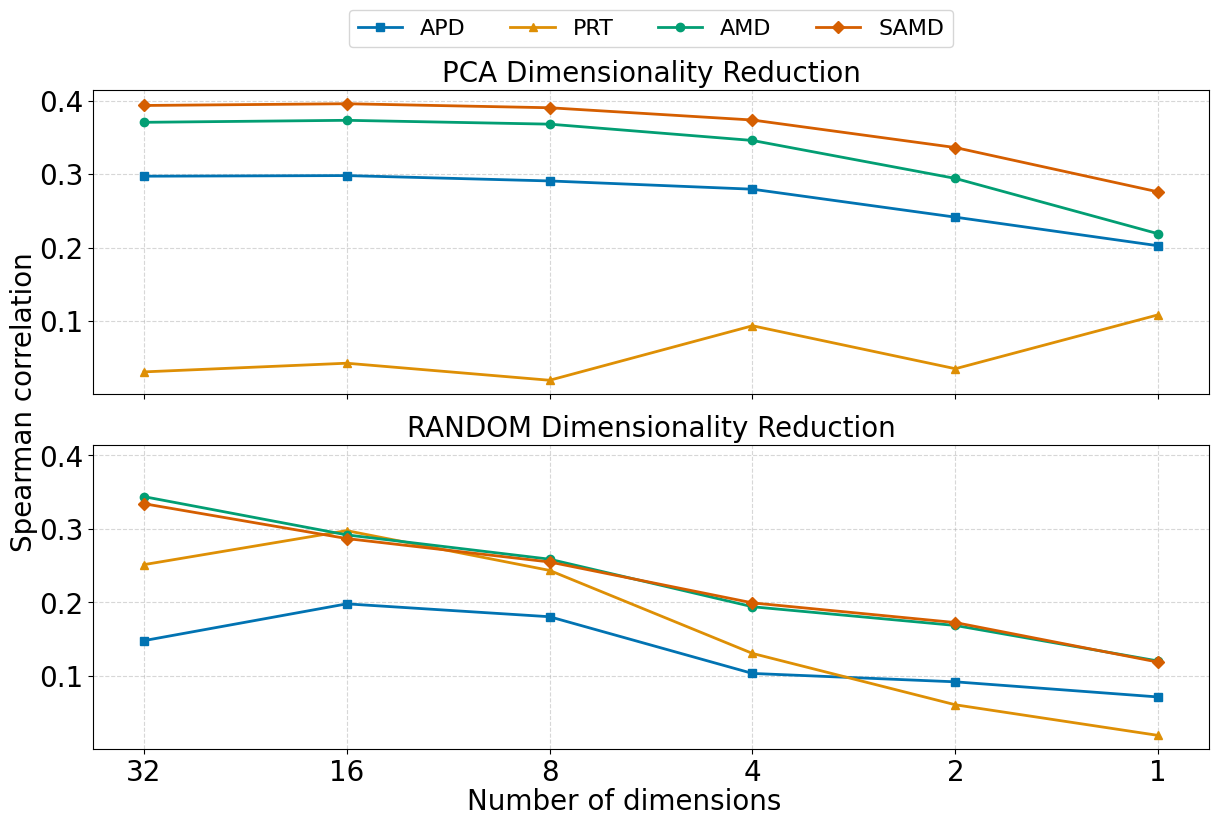

In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt

FONT_SIZE = 20  # change this to scale everything

dims = [32, 16, 8, 4, 2, 1]
metrics = ["apd", "prt", "amd", "samd"]
spaces = ["pca", "random"]  # will plot each if columns exist

def extract_series(mean_row, std_row, metric, space, dims):
    """Return y (means) and e (stds) aligned to dims for a given metric+space."""
    y, e = [], []
    for k in dims:
        col = f"{metric}_{space}_num{k}"
        y.append(mean_row.get(col, np.nan))
        e.append(std_row.get(col, np.nan))
    print(y,e)
    return np.array(y, dtype=float), np.array(e, dtype=float)

# Grab the Average row (works whether Average is an index or a column)
def get_average_row(df):
    if "Average" in df.index:
        return df.loc["Average"]
    if "Average" in df.columns:
        # If it's a column with labels, assume there's a row named Average elsewhere
        raise ValueError("mean_df has an 'Average' column, not an index. Please set it as index or provide row selection.")
    else:
        # create an average row
        avg_row = df.mean(numeric_only=True)
        return avg_row
    raise ValueError("Could not find 'Average' in df.index. Ensure 'Average' is an index label.")

mean_row = get_average_row(mean_df)
std_row  = get_average_row(std_df)


offsets = {
    "apd": -0.06,
    "prt":  0.00,
    "amd":  0.06,
    "samd": 0.12,
}

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharey=True)

colorblind_palette = sns.color_palette("colorblind")
sns.set_palette(colorblind_palette)
colors = sns.color_palette("colorblind", n_colors=4)

for ax, space in zip(axes, spaces):
    any_plotted = False
    for m in metrics:
        y, e = extract_series(mean_row, std_row, m, space, dims)
        print(f"Plotting metric {m} in space {space}: y={y}, e={e}") # y=[nan nan nan nan nan nan], e=[nan nan nan nan nan nan] for every metric/space combo

        # Only plot if at least one value exists
        if np.isfinite(y).any():
            any_plotted = True

            dims_shifted = dims # [d * (2 ** offsets[m]) for d in dims]

            if m == 'prt':
                marker = '^'
            elif m == 'apd':
                marker = 's'
            elif m == 'amd':
                marker = 'o'
            elif m == 'samd':
                marker = 'D'
            ax.errorbar(
                dims_shifted, y, yerr=None,
                marker=marker, linewidth=2, capsize=3,
                label=m.upper(), color=colors[metrics.index(m)]
            )

    if not any_plotted:
        ax.set_visible(False)
        continue

    ax.set_xscale("log", base=2)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.set_title(f"{space.upper()} Dimensionality Reduction",fontsize=FONT_SIZE)

    ax.grid(True, linestyle="--", alpha=0.5)

    ax.invert_xaxis()


# add a joint xlabel and ylabel
fig.text(0.5, 0.0, "Number of dimensions", ha='center', va='center', fontsize=FONT_SIZE)
fig.text(0.0, 0.5, "Spearman correlation", ha='center', va='center', rotation='vertical', fontsize=FONT_SIZE)
axes[1].set_xticks(dims)
# drop x_ticks from top plot
axes[0].set_xticklabels([])

# add legend in top right above plot
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4, fontsize=FONT_SIZE-4)

plt.tight_layout()
plt.show()
